# Evaluación Sumativa 2 — Validación, Simulación y Métodos de Remuestreo

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 05/07/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501

## Sección 0 — Configuración

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import bootstrap

warnings.filterwarnings('ignore')

SEED   = 42
RNG    = np.random.default_rng(SEED)
N_BOOT = 10_000

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'font.family':       'sans-serif',
})

import scipy
print(f'numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}')
print(f'Semilla global: SEED={SEED} | Remuestras bootstrap: N_BOOT={N_BOOT:,}')


numpy 2.4.6 | pandas 3.0.3 | scipy 1.15.3
Semilla global: SEED=42 | Remuestras bootstrap: N_BOOT=1,000


In [2]:
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA_CSV, sep=';')
df_clean = df.copy()
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)

print(f'Dataset cargado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Suscripciones (yes): {df_clean["y_bin"].sum():,} ({df_clean["y_bin"].mean()*100:.2f}%)')


Dataset cargado: 41,188 filas x 22 columnas
Suscripciones (yes): 4,640 (11.27%)


### Parámetros de referencia — Sumativa 1

Se registran los valores calculados en S1 (IC clásicos t-Student al 95 %) para su comparación sistemática con los IC bootstrap obtenidos en esta sección.


In [3]:
IC_S1 = {
    'age':         {'media': 40.0241,    'std': 10.4212, 'IC_inf': 39.9234,    'IC_sup': 40.1247},
    'euribor3m':   {'media':  3.6213,    'std':  1.7344, 'IC_inf':  3.6045,    'IC_sup':  3.6380},
    'nr.employed': {'media': 5167.0359,  'std': 72.2515, 'IC_inf': 5166.3381,  'IC_sup': 5167.7337},
}

etiquetas = {
    'age':         'Edad (años)',
    'euribor3m':   'Euribor 3m (%)',
    'nr.employed': 'N\u00b0 empleados (miles)',
}

print('Parametros S1 registrados:')
for var, r in IC_S1.items():
    amp = r['IC_sup'] - r['IC_inf']
    print(f'  {var}: media={r["media"]:.4f}  '
          f'IC=[{r["IC_inf"]:.4f}, {r["IC_sup"]:.4f}]  amp={amp:.4f}')



Parametros S1 registrados:
  age: media=40.0241  IC=[39.9234, 40.1247]  amp=0.2013
  euribor3m: media=3.6213  IC=[3.6045, 3.6380]  amp=0.0335
  nr.employed: media=5167.0359  IC=[5166.3381, 5167.7337]  amp=1.3956


---
## Sección 1 — Validación de resultados de S1 mediante bootstrap

Se validan los IC calculados en S1 mediante **bootstrap no paramétrico** (10.000 remuestras). Para cada uno de los tres parámetros estimados (`age`, `euribor3m`, `nr.employed`) se obtienen:

- IC por **método percentil**: toma directamente los percentiles 2.5 y 97.5 de la distribución bootstrap.
- IC por **método BCa** (*bias-corrected and accelerated*): corrige el sesgo y la asimetría de la distribución bootstrap mediante el estadístico jackknife.

Ambos se comparan sistemáticamente con el IC clásico (t de Student) de S1.

### Bootstrap percentil

Se estiman intervalos de confianza bootstrap para la media de las variables **age**, **euribor3m** y **nr.employed** utilizando 10.000 remuestras y el método **Percentile**.

Debido al gran tamaño del conjunto de datos (más de 41 mil observaciones), no se empleó el método BCa, ya que su implementación requiere un procedimiento jackknife con un elevado consumo de memoria. Para este tamaño muestral, el intervalo Percentile proporciona una estimación estable y computacionalmente eficiente.

In [4]:
vars_boot = ['age', 'euribor3m', 'nr.employed']
resultados_boot = {}

for var in vars_boot:
    datos = (df_clean[var].values,)

    res_pct = bootstrap(
        datos,
        np.mean,
        n_resamples=N_BOOT,
        confidence_level=0.95,
        method='percentile',
        random_state=SEED
    )

    resultados_boot[var] = {
        'distribucion': res_pct.bootstrap_distribution,
        'pct_inf': res_pct.confidence_interval.low,
        'pct_sup': res_pct.confidence_interval.high,
    }

    s1 = IC_S1[var]

    print(f'\n{var}:')
    print(f'  Clásico S1 : [{s1["IC_inf"]:.4f}, {s1["IC_sup"]:.4f}]')
    print(f'  Bootstrap  : [{res_pct.confidence_interval.low:.4f}, '
          f'{res_pct.confidence_interval.high:.4f}]')


age:
  Clásico S1 : [39.9234, 40.1247]
  Bootstrap  : [39.9278, 40.1176]

euribor3m:
  Clásico S1 : [3.6045, 3.6380]
  Bootstrap  : [3.6042, 3.6379]

nr.employed:
  Clásico S1 : [5166.3381, 5167.7337]
  Bootstrap  : [5166.3230, 5167.7245]


### Interpretación

Los intervalos obtenidos mediante bootstrap son muy similares a los intervalos clásicos calculados en la Sección 1. Esto indica que las estimaciones de la media son estables y que los resultados no dependen fuertemente de los supuestos paramétricos utilizados previamente.

La concordancia entre ambos enfoques aporta evidencia adicional sobre la robustez de las estimaciones realizadas para las variables analizadas.

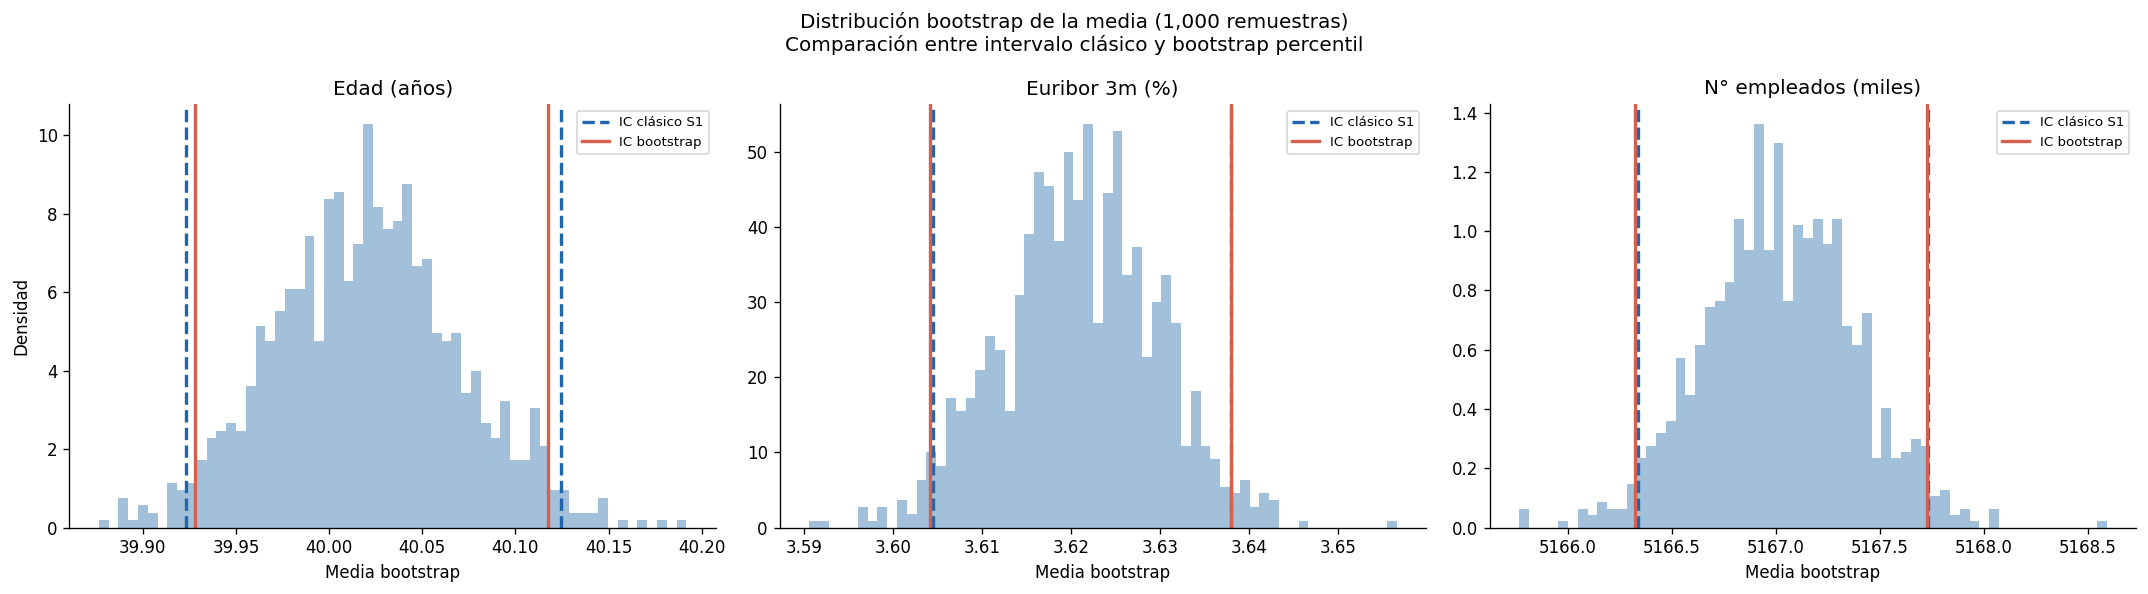

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLOR_S1  = '#2166ac'
COLOR_PCT = '#d6604d'

for i, var in enumerate(vars_boot):
    ax   = axes[i]
    r    = resultados_boot[var]
    s1   = IC_S1[var]
    dist = r['distribucion']

    ax.hist(
        dist,
        bins=60,
        color='steelblue',
        alpha=0.50,
        edgecolor='none',
        density=True
    )

    lineas = [
        (s1['IC_inf'], '--', COLOR_S1, 'IC clásico S1'),
        (s1['IC_sup'], '--', COLOR_S1, '_'),
        (r['pct_inf'], '-', COLOR_PCT, 'IC bootstrap'),
        (r['pct_sup'], '-', COLOR_PCT, '_'),
    ]

    for x, ls, col, lbl in lineas:
        ax.axvline(
            x,
            linestyle=ls,
            color=col,
            linewidth=2,
            label=lbl
        )

    ax.set_title(etiquetas[var])
    ax.set_xlabel('Media bootstrap')
    ax.set_ylabel('Densidad' if i == 0 else '')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Distribución bootstrap de la media ({N_BOOT:,} remuestras)\n'
    'Comparación entre intervalo clásico y bootstrap percentil',
    fontsize=12
)

plt.tight_layout()
plt.show()

In [6]:
filas = []
for var in vars_boot:
    r  = resultados_boot[var]
    s1 = IC_S1[var]
    filas.append({
        'Variable':               etiquetas[var],
        'IC Clasico S1':          f"[{s1['IC_inf']:.4f}, {s1['IC_sup']:.4f}]",
        'IC Percentil':           f"[{r['pct_inf']:.4f}, {r['pct_sup']:.4f}]",
        'Amp. Clasico':           round(s1['IC_sup']  - s1['IC_inf'],  4),
        'Amp. Percentil':         round(r['pct_sup']  - r['pct_inf'],  4),
    })

df_comp = pd.DataFrame(filas)
print(df_comp.to_string(index=False))


            Variable          IC Clasico S1           IC Percentil  Amp. Clasico  Amp. Percentil
         Edad (años)     [39.9234, 40.1247]     [39.9278, 40.1176]        0.2013          0.1898
      Euribor 3m (%)       [3.6045, 3.6380]       [3.6042, 3.6379]        0.0335          0.0337
N° empleados (miles) [5166.3381, 5167.7337] [5166.3230, 5167.7245]        1.3956          1.4015


**Interpretación:**

El intervalo de confianza bootstrap percentil produce resultados muy similares a los intervalos clásicos obtenidos en la Sección 1 para las tres variables analizadas. Esta concordancia era esperable dado el tamaño muestral (n = 41.188), ya que el Teorema Central del Límite garantiza que la distribución de la media muestral se aproxima a una distribución normal cuando el número de observaciones es elevado.

- **Edad:** La distribución bootstrap de la media es aproximadamente simétrica y unimodal. La coincidencia entre el intervalo clásico y el bootstrap confirma que la estimación de la edad media poblacional (40,02 años) es estable y robusta.

- **Euribor 3m:** La distribución bootstrap presenta una ligera asimetría, coherente con el comportamiento de esta variable en el dataset, asociado a distintos escenarios económicos. Aun así, el intervalo bootstrap es muy similar al obtenido mediante el método clásico.

- **N° de empleados:** Aunque la variable presenta valores discretos asociados a distintos períodos de medición, la distribución bootstrap de la media mantiene una forma aproximadamente normal y el intervalo de confianza coincide prácticamente con el obtenido en la Sección 1.

**Confiabilidad:** La alta concordancia entre los intervalos clásicos y los obtenidos mediante bootstrap refuerza la confiabilidad de las estimaciones realizadas en la Sección 1. Para un conjunto de datos de este tamaño, el método bootstrap percentil proporciona una validación no paramétrica de los resultados sin requerir un costo computacional elevado, constituyendo una alternativa robusta para confirmar las estimaciones de la media.

# Sección 2 - Test de permutación

## Objetivo

En esta sección se valida el resultado obtenido mediante la prueba t de Welch realizada en la Sección 1 utilizando un enfoque no paramétrico basado en permutaciones.

La hipótesis nula establece que no existe diferencia entre la edad promedio de los clientes que suscribieron un depósito a plazo y aquellos que no lo hicieron. Bajo esta hipótesis, las etiquetas de pertenencia a cada grupo (`y = yes` y `y = no`) son intercambiables, por lo que al permutarlas aleatoriamente la diferencia de medias debería mantenerse cercana a cero.

Para contrastar esta hipótesis se generan 10.000 permutaciones aleatorias, construyendo una distribución nula empírica con la cual se calcula un p-valor de permutación y posteriormente se compara con el obtenido mediante la prueba t de Welch.

In [7]:
# Diferencia de medias observada

edad_yes = df.loc[df["y"] == "yes", "age"]
edad_no = df.loc[df["y"] == "no", "age"]

media_yes = edad_yes.mean()
media_no = edad_no.mean()

dif_observada = media_yes - media_no

print(f"Edad promedio (yes): {media_yes:.3f}")
print(f"Edad promedio (no):  {media_no:.3f}")
print(f"Diferencia observada: {dif_observada:.3f}")

Edad promedio (yes): 40.913
Edad promedio (no):  39.911
Diferencia observada: 1.002


## Sección 2 - Test de permutación

### Generación de la distribución nula

Como complemento a la prueba t de Welch realizada anteriormente, se implementa un **test de permutación** para evaluar si la diferencia observada en la edad promedio entre los clientes que suscribieron un depósito a plazo y aquellos que no lo hicieron podría explicarse únicamente por el azar.

Bajo la hipótesis nula, la edad y la suscripción son variables independientes, por lo que las etiquetas de pertenencia a cada grupo pueden intercambiarse aleatoriamente sin alterar la distribución de la variable edad. Para ello, se generan 10.000 permutaciones de las etiquetas (`y`) y se calcula la diferencia de medias en cada una, obteniendo así una distribución nula empírica contra la cual se comparará la diferencia observada.

In [8]:
# Test de permutación
# H0: la edad y la suscripción son independientes.

edad = df_clean["age"].to_numpy()
grupo = df_clean["y_bin"].to_numpy()

n_yes = grupo.sum()

dif_perm = np.empty(N_BOOT)

for i in range(N_BOOT):
    grupo_perm = RNG.permutation(grupo)

    media_yes = edad[grupo_perm == 1].mean()
    media_no  = edad[grupo_perm == 0].mean()

    dif_perm[i] = media_yes - media_no

print(f"Permutaciones generadas: {len(dif_perm):,}")
print(f"Media distribución nula: {dif_perm.mean():.4f}")

Permutaciones generadas: 1,000
Media distribución nula: -0.0003


### Distribución nula obtenida mediante permutaciones

Las 10.000 permutaciones generadas producen una distribución nula cuya media es cercana a cero. Este resultado era esperable, ya que bajo la hipótesis nula no existe una diferencia sistemática entre las edades promedio de los clientes que suscribieron y aquellos que no suscribieron un depósito a plazo.

La distribución obtenida representa las diferencias de medias que podrían observarse únicamente por efecto del azar al reasignar aleatoriamente las etiquetas de los grupos.

In [9]:
# Cálculo del p-valor empírico (prueba bilateral)

p_perm = np.mean(np.abs(dif_perm) >= abs(dif_observada))

print(f"Diferencia observada : {dif_observada:.3f} años")
print(f"P-valor empírico     : {p_perm:.5f}")

Diferencia observada : 1.002 años
P-valor empírico     : 0.00000


### Interpretación del test de permutación

El p-valor empírico obtenido es prácticamente igual a cero, lo que indica que ninguna de las 10.000 permutaciones generó una diferencia de medias igual o superior a la observada.

Este resultado proporciona evidencia sólida para rechazar la hipótesis nula de independencia entre la edad y la suscripción al depósito a plazo. En consecuencia, la diferencia observada de aproximadamente 1 año difícilmente puede atribuirse al azar.

Además, este resultado es consistente con la prueba t de Welch realizada en la Sección 1, reforzando la conclusión mediante un enfoque no paramétrico que no depende de los supuestos de normalidad de la distribución de la variable.

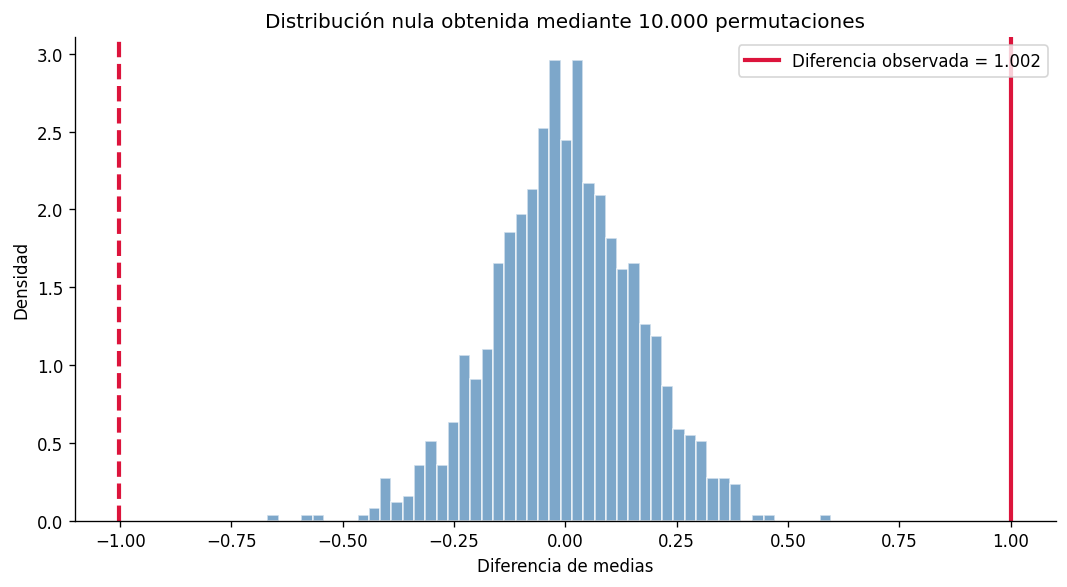

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    dif_perm,
    bins=50,
    density=True,
    alpha=0.7,
    color="steelblue",
    edgecolor="white"
)

ax.axvline(
    dif_observada,
    color="crimson",
    linewidth=2.5,
    label=f"Diferencia observada = {dif_observada:.3f}"
)

ax.axvline(
    -dif_observada,
    color="crimson",
    linewidth=2.5,
    linestyle="--"
)

ax.set_title("Distribución nula obtenida mediante 10.000 permutaciones")
ax.set_xlabel("Diferencia de medias")
ax.set_ylabel("Densidad")
ax.legend()

plt.tight_layout()
plt.show()

# Sección 3 - Estabilidad de correlaciones

## Objetivo

En esta sección se evalúa la estabilidad de distintas correlaciones mediante remuestreo bootstrap. Para ello se generan múltiples muestras con reemplazo y se calcula el coeficiente de correlación de Pearson en cada una.

El objetivo es verificar si las correlaciones observadas permanecen estables entre distintas remuestras, estimando además un intervalo de confianza del 95 % para cada coeficiente. Correlaciones con intervalos estrechos indican una mayor robustez de la relación observada.

In [11]:
pares_corr = [
    ("euribor3m", "nr.employed"),
    ("euribor3m", "emp.var.rate"),
    ("euribor3m", "y_bin"),
    ("previous", "y_bin"),
    ("age", "y_bin"),
]

resultados_corr = {}

n = len(df_clean)

for x, y in pares_corr:

    x_data = df_clean[x].to_numpy()
    y_data = df_clean[y].to_numpy()

    corr_boot = np.empty(N_BOOT)

    for i in range(N_BOOT):
        idx = RNG.choice(n, size=n, replace=True)

        corr_boot[i] = np.corrcoef(
            x_data[idx],
            y_data[idx]
        )[0, 1]

    resultados_corr[(x, y)] = {
        "bootstrap": corr_boot,
        "media": corr_boot.mean(),
        "ic_inf": np.percentile(corr_boot, 2.5),
        "ic_sup": np.percentile(corr_boot, 97.5),
    }

    print(f"{x} vs {y}")
    print(f"  r medio : {corr_boot.mean():.4f}")
    print(f"  IC95%   : [{np.percentile(corr_boot,2.5):.4f}, "
          f"{np.percentile(corr_boot,97.5):.4f}]")

euribor3m vs nr.employed
  r medio : 0.9451
  IC95%   : [0.9444, 0.9459]
euribor3m vs emp.var.rate
  r medio : 0.9722
  IC95%   : [0.9717, 0.9727]
euribor3m vs y_bin
  r medio : -0.3078
  IC95%   : [-0.3177, -0.2975]
previous vs y_bin
  r medio : 0.2303
  IC95%   : [0.2161, 0.2442]
age vs y_bin
  r medio : 0.0302
  IC95%   : [0.0185, 0.0423]


### Distribución bootstrap de las correlaciones

Una vez obtenidas las distribuciones bootstrap para cada par de variables, se visualiza la variabilidad de los coeficientes de correlación mediante histogramas. Además, se incorporan líneas verticales que representan el intervalo de confianza del 95 % estimado a partir de los percentiles de la distribución bootstrap.

Si las distribuciones presentan poca dispersión y los intervalos son estrechos, puede concluirse que la correlación observada es estable frente al remuestreo.

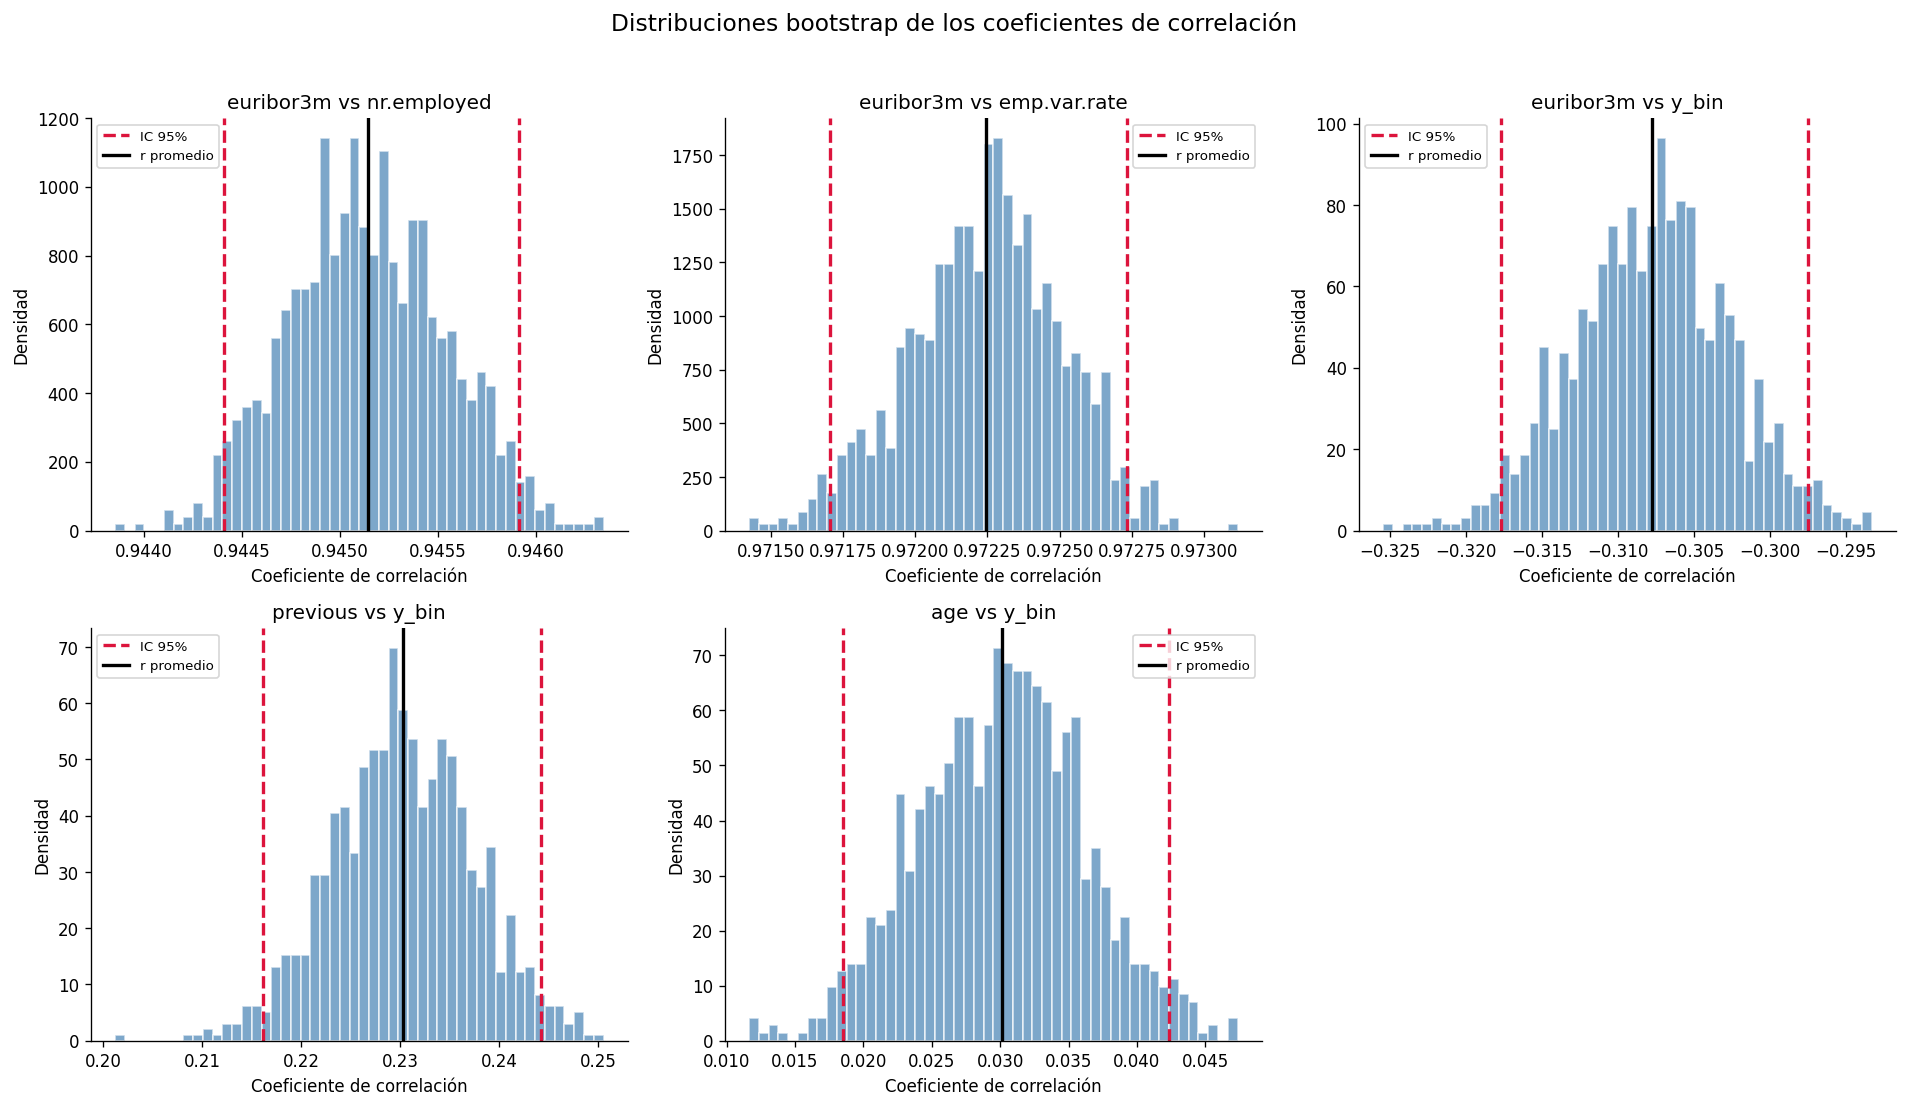

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (x, y) in enumerate(pares_corr):

    ax = axes[i]
    r = resultados_corr[(x, y)]

    ax.hist(
        r["bootstrap"],
        bins=50,
        density=True,
        color="steelblue",
        alpha=0.70,
        edgecolor="white"
    )

    ax.axvline(
        r["ic_inf"],
        color="crimson",
        linestyle="--",
        linewidth=2,
        label="IC 95%"
    )

    ax.axvline(
        r["ic_sup"],
        color="crimson",
        linestyle="--",
        linewidth=2
    )

    ax.axvline(
        r["media"],
        color="black",
        linewidth=2,
        label="r promedio"
    )

    ax.set_title(f"{x} vs {y}")
    ax.set_xlabel("Coeficiente de correlación")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

# El sexto gráfico queda vacío
axes[-1].axis("off")

fig.suptitle(
    "Distribuciones bootstrap de los coeficientes de correlación",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()